In [1]:

import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import matplotlib


notebook_dir = Path().absolute()
if notebook_dir.name == 'examples':
    os.chdir(notebook_dir.parent)

from src.dataset import NeuroscienceDataset, compute_omega_from_timeseries
from src.models import CoupledHopfModel

%matplotlib inline

In [2]:
dataset = NeuroscienceDataset("data/ts_young/ts_young_TR0.72.mat", normalize=True, max_subjects=2, fourier_denoise=False)
omega = compute_omega_from_timeseries(dataset.timeseries)

In [ ]:
patient = 0
n_steps = 40

model = CoupledHopfModel(
    n_rois=100,
    initial_a=-0.02,
    initial_g=1.5, 
    initial_kappa=0.3,
    noise_sigma=0.2,
    omega=omega,
    structural_connectivity=dataset.fc_mean
)

# Simulate 200 timepoints
with torch.no_grad():
    z0 = dataset.timeseries[:, :, 0]  # complex initial conditions
    zs = model.forward(initial_state=z0, n_steps=n_steps)  # (10, 68, 200) complex
    fc_matrix = model.compute_fc(zs)     

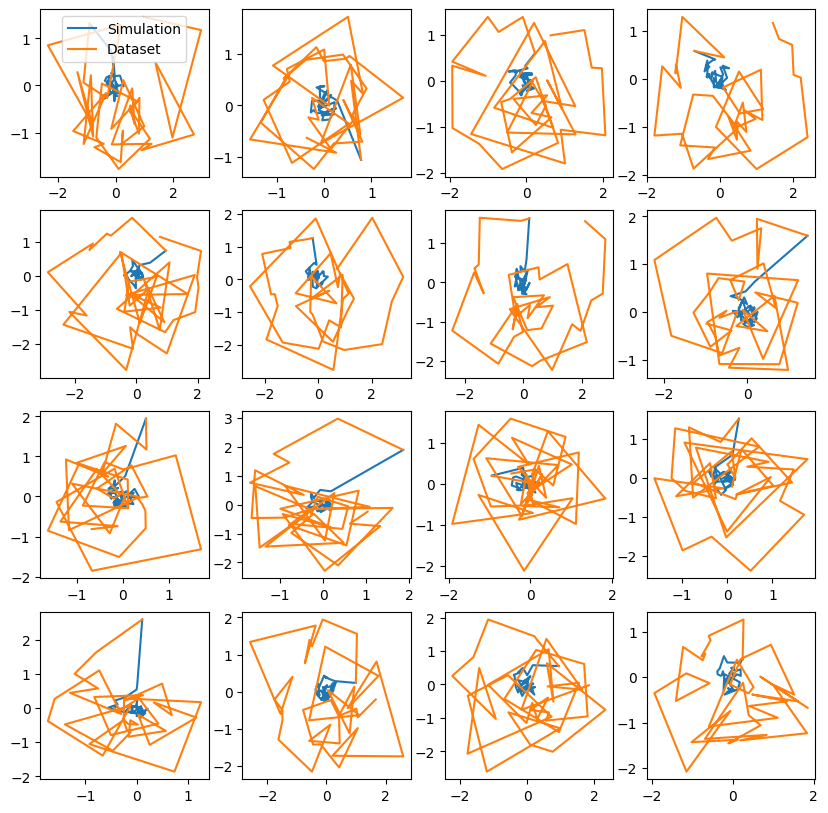

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.reshape(-1)
for i in range(4*4):
    axes[i].plot(zs[patient, i].real, zs[patient, i].imag, label="Simulation")
    axes[i].plot(dataset.timeseries[patient, i, :n_steps].real, dataset.timeseries[patient, i, :n_steps].imag, label="Dataset")
axes[0].legend()
plt.show()